# EDA — Procura, Geografia, Demografia e Origem Escolar dos candidatos
vazios por coluna, procura por curso, validação cruzada de códigos,
geografia (província/distrito), estrangeiros, demografia (sexo/idade/estado civil), escola de
origem, ano de conclusão do secundário, local de exame, e uma síntese final de insights.

In [1]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df_candidatos = pd.read_parquet('../data/processed/candidatos_uem.parquet')
df_cursos = pd.read_excel('../data/raw/Cursos_UEM_2026.xlsx')

print(df_candidatos.shape) 
df_candidatos.head(16)

(26798, 23)


,Ano,candidato_codigo,apelido,nome,TipoDoc,DocIdent,Sexo,EstCivil,pais_nascimento,ProvNasc,ProvRes,ProvCand,cod_preUni,EscoPU,local_exame,AnocPU,distrito_nascimento,distrito_residencia,UEM_Cod_Opc1,UEM_Opc1,UEM_Cod_Opc2,UEM_Opc2,data_Nasc
0,2026,10019,SUARES,SONIA,BILHETE DE IDENTIDADE,1233444,Feminino,Solteiro(A),Andorra,Estrangeiro,Cabo Delgado,Cidade de Maputo,6.0,Colégio Delta,Chibuto,2012,Estrangeiro,Pemba Cidade,10100,Administração Pública - Diurno - Uem,10128,Arqueologia E Gestão Do Património Cultural - ...,2011-12-11
1,2026,10039,MUARAPAZ,CLÁUDIO ARMANDO,BILHETE DE IDENTIDADE,030106033801F,Masculino,Solteiro(A),Mocambique,Nampula,Cidade de Maputo,Nampula,833.0,Escola Secundária De Teacane,Cidade De Maputo,2022,Cidade De Nampula,Kamaxaquene,10300,Economia - Diurno - Uem,10302,Contabilidade E Finanças - Diurno - Uem,2004-05-07
2,2026,10041,MBALANGO,YUNI ADELAIDE ANÍBAL,BILHETE DE IDENTIDADE,110107852412P,Feminino,Solteiro(A),Mocambique,Cidade De Maputo,Província de Maputo,Cidade de Maputo,3.0,Instituto Comercial De Maputo,Cidade De Maputo,2025,Kampfumo,Matola Cidade,10300,Economia - Diurno - Uem,10302,Contabilidade E Finanças - Diurno - Uem,2007-10-13
3,2026,10058,SARMENTO,NENGRA AURO,BILHETE DE IDENTIDADE,100107127647P,Feminino,Solteiro(A),Mocambique,Província De Maputo,Província de Maputo,Província de Maputo,140.0,Escola Secundária De Machava Sede,Província De Maputo,2024,Matola Cidade,Matola Cidade,10300,Economia - Diurno - Uem,10302,Contabilidade E Finanças - Diurno - Uem,2007-06-27
4,2026,10062,SEBASTIÃO,LOIDA JOSEFA,BILHETE DE IDENTIDADE,110207815487J,Feminino,Solteiro(A),Mocambique,Cidade De Maputo,Cidade de Maputo,Cidade de Maputo,2.0,Escola Secundária Josina Machel,Cidade De Maputo,2023,Kanlhamankulu,Kanlhamankulu,10208,Desenvolvimento E Educação De Infância - Diurn...,10204,Educação Ambiental (Por-Iii E Bio-Ii) - Diurno...,2004-09-17
5,2026,10068,USTÁ,SULLEN MUHUTAR MOMADE,BILHETE DE IDENTIDADE,110108970807J,Masculino,Solteiro(A),Mocambique,Cidade De Maputo,Província de Maputo,Província de Maputo,199.0,Outra - Província De Maputo,Província De Maputo,2025,Kampfumo,Matola Cidade,10302,Contabilidade E Finanças - Diurno - Uem,10304,Gestão - Diurno - Uem,2006-12-30
6,2026,10079,ROMEUANE,TAMIA CAROLINE,BILHETE DE IDENTIDADE,110204168117M,Feminino,Solteiro(A),Mocambique,Cidade De Maputo,Cidade de Maputo,Cidade de Maputo,0.0,Desconhecida - Cidade De Maputo,Cidade De Maputo,2022,Kampfumo,Kampfumo,10304,Gestão - Diurno - Uem,10300,Economia - Diurno - Uem,2003-12-23
7,2026,10065,JAIME,EDMILSON TOMÉ MANUEL,BILHETE DE IDENTIDADE,050108868944J,Masculino,Solteiro(A),Mocambique,Tete,Tete,Tete,699.0,Outra - Província De Tete,Cidade De Tete,2022,Cidade De Tete,Cidade De Tete,11100,Engenharia Civil - Diurno - Uem,11104,Engenharia Eléctrica - Diurno - Uem,2003-12-15
8,2026,10066,DRAIVA,OSVALDO TIAGO,BILHETE DE IDENTIDADE,O60206607462f,Masculino,Solteiro(A),Mocambique,Manica,Cidade de Maputo,Manica,508.0,Escola Secundária Armando E Guebuza,Cidade De Maputo,2025,Barue,Katembe,10600,Direito - Diurno - Uem,0,Sem Opcao,1998-06-12
9,2026,10096,JUMA,MATANO NAHOTA,BILHETE DE IDENTIDADE,031808870232M,Masculino,Solteiro(A),Mocambique,Nampula,Nampula,Nampula,457.0,Escola Secundária 25 De Setembro,Cidade De Nampula,2024,Nacala-Velha,Nacala-Velha,10106,Ensino De Francês - Diurno - Uem,10124,Tradução Português/Francês - Diurno - Uem,2004-12-27


In [3]:
vazios = (df_candidatos.isnull().sum() / len(df_candidatos) * 100).sort_values(ascending=False)
vazios = vazios[vazios > 0]
print(f'Percentual de valores nulos por coluna:\n{vazios}')

Percentual de valores nulos por coluna:
cod_preUni             0.108217
Sexo                   0.003732
apelido                0.003732
pais_nascimento        0.003732
ProvNasc               0.003732
EstCivil               0.003732
nome                   0.003732
ProvRes                0.003732
data_Nasc              0.003732
distrito_residencia    0.003732
distrito_nascimento    0.003732
dtype: float64


## 1. Procura por curso (1ª opção)
Quantos candidatos escolheram cada curso como primeira opção.

In [4]:
procura_opc1 = df_candidatos['UEM_Opc1'].value_counts().reset_index()
procura_opc1.columns = ['curso', 'candidatos_1a_opcao']
procura_opc1.head(15)

,curso,candidatos_1a_opcao
0,Medicina - Diurno - Uem,3508
1,Direito - Diurno - Uem,2154
2,Engenharia Informática - Diurno - Uem,1626
3,Contabilidade E Finanças - Diurno - Uem,1589
4,Engenharia Eléctrica - Diurno - Uem,1280
5,Engenharia Mecânica - Diurno - Uem,1191
6,Engenharia De Petróleo E Gás Natural - Diurno ...,1188
7,Engenharia Civil - Diurno - Uem,939
8,Gestão - Diurno - Uem,796
9,Administração Pública - Diurno - Uem,795


In [5]:
procura_opc2 = df_candidatos[df_candidatos['UEM_Opc2'] != 'Sem Opcao']['UEM_Opc2'].value_counts().reset_index()
procura_opc2.columns = ['curso', 'candidatos_2a_opcao']

procura_total = procura_opc1.merge(procura_opc2, on='curso', how='outer').fillna(0)
procura_total['candidatos_1a_opcao'] = procura_total['candidatos_1a_opcao'].astype(int)
procura_total['candidatos_2a_opcao'] = procura_total['candidatos_2a_opcao'].astype(int)
procura_total['total'] = procura_total['candidatos_1a_opcao'] + procura_total['candidatos_2a_opcao']
procura_total = procura_total.sort_values('total', ascending=False)
procura_total.head(15)

,curso,candidatos_1a_opcao,candidatos_2a_opcao,total
122,Medicina - Diurno - Uem,3508,170,3678
34,Direito - Diurno - Uem,2154,320,2474
63,Engenharia Informática - Diurno - Uem,1626,755,2381
30,Contabilidade E Finanças - Diurno - Uem,1589,614,2203
52,Engenharia De Petróleo E Gás Natural - Diurno ...,1188,935,2123
17,Biologia E Saúde - Diurno - Uem,409,1550,1959
60,Engenharia Eléctrica - Diurno - Uem,1280,678,1958
65,Engenharia Mecânica - Diurno - Uem,1191,564,1755
98,Gestão - Diurno - Uem,796,855,1651
0,Administração Pública - Diurno - Uem,795,847,1642


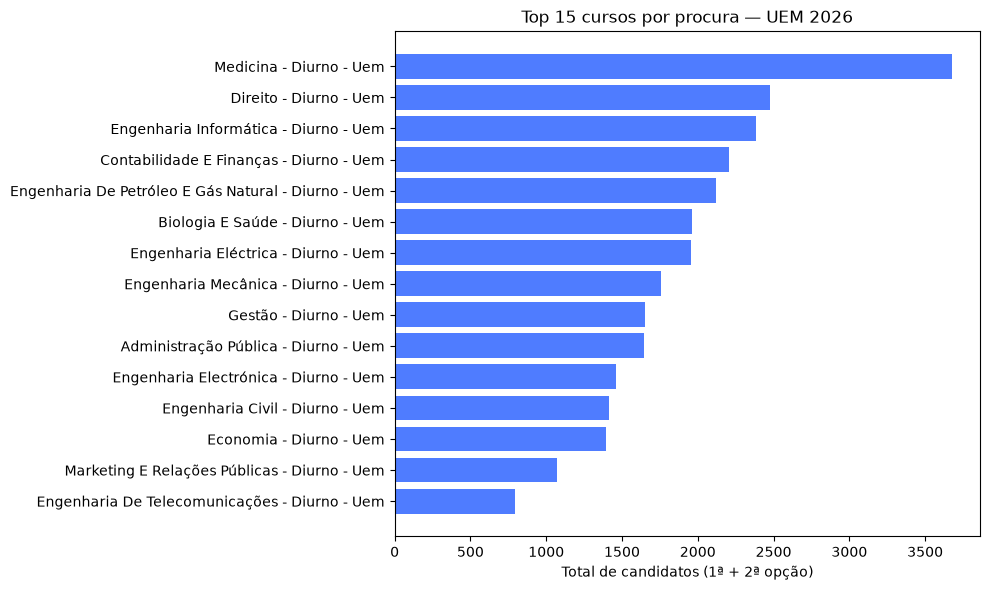

In [6]:
top15 = procura_total.head(15)
plt.figure(figsize=(10, 6))
plt.barh(top15['curso'], top15['total'], color='#4F7CFF')
plt.gca().invert_yaxis()
plt.xlabel('Total de candidatos (1ª + 2ª opção)')
plt.title('Top 15 cursos por procura — UEM 2026')
plt.tight_layout()
plt.show()

In [7]:
#Verificar as colunas disponíveis
print("Colunas de df_cursos:", df_cursos.columns.tolist())

# Encontrar a coluna de código de curso
col_codigo = None
for col in df_cursos.columns:
    if 'cod' in col.lower():
        col_codigo = col
        break

if col_codigo is None:
    print("Aviso: Nenhuma coluna com 'cod' encontrada em df_cursos")
else:
    codigos_oficiais = set(df_cursos[col_codigo].unique())
    codigos_usados_opc1 = set(df_candidatos['UEM_Cod_Opc1'].dropna().unique())
    codigos_usados_opc2 = set(df_candidatos[df_candidatos['UEM_Cod_Opc2'] != 0]['UEM_Cod_Opc2'].dropna().unique())
    
    nao_reconhecidos = (codigos_usados_opc1 | codigos_usados_opc2) - codigos_oficiais
    print("Códigos de curso usados por candidatos mas ausentes na lista oficial:")
    print(nao_reconhecidos if nao_reconhecidos else "Nenhum código não reconhecido")

Colunas de df_cursos: ['Código', 'Designação do Curso', 'Período']
Aviso: Nenhuma coluna com 'cod' encontrada em df_cursos


Candidatos por província de nascimento: ProvNasc
Cidade De Maputo       12404
Província De Maputo     5548
Gaza                    1991
Inhambane               1954
Zambezia                1249
Nampula                 1046
Sofala                   985
Manica                   541
Cabo Delgado             357
Tete                     317
Niassa                   286
Estrangeiro              119
Name: count, dtype: int64


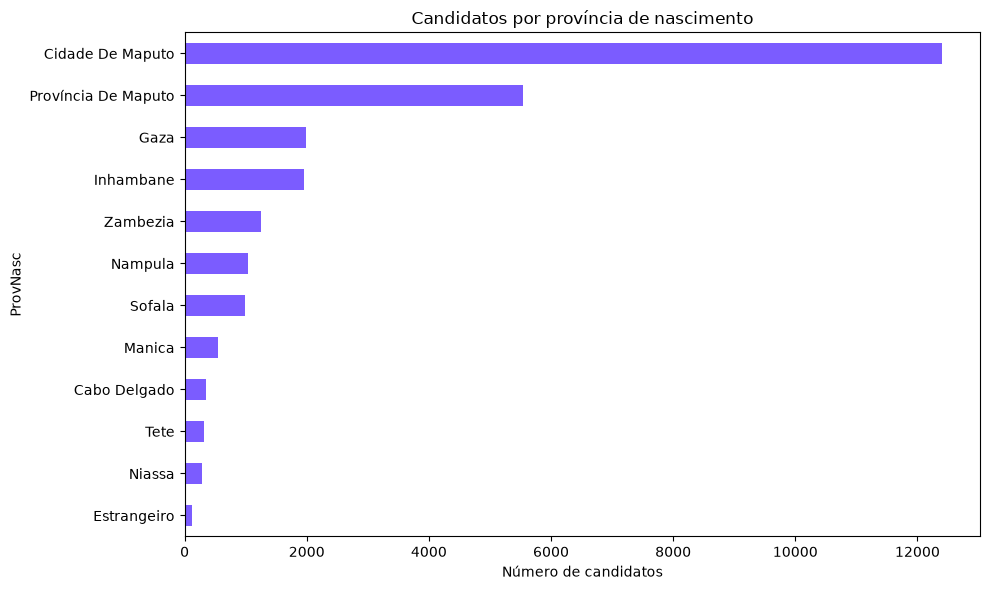

In [8]:
por_provincia = df_candidatos['ProvNasc'].value_counts()
print(f"Candidatos por província de nascimento: {por_provincia}")

plt.figure(figsize=(10, 6))
por_provincia.plot(kind='barh', color='#7B5CFF')
plt.gca().invert_yaxis()
plt.xlabel('Número de candidatos')
plt.title('Candidatos por província de nascimento')
plt.tight_layout()
plt.show()

In [9]:
print("Província de Residência:")
print(df_candidatos['ProvRes'].value_counts())
cruzamento_prov = pd.crosstab(df_candidatos['ProvNasc'], df_candidatos['ProvRes'])
cruzamento_prov 

Província de Residência:
ProvRes
Cidade de Maputo       10957
Província de Maputo     9475
Gaza                    1478
Inhambane               1293
Nampula                  831
Zambezia                 738
Sofala                   668
Manica                   451
Tete                     352
Cabo Delgado             315
Niassa                   238
Estrangeiro                1
Name: count, dtype: int64


ProvRes,Cabo Delgado,Cidade de Maputo,Estrangeiro,Gaza,Inhambane,Manica,Nampula,Niassa,Província de Maputo,Sofala,Tete,Zambezia
ProvNasc,,,,,,,,,,,,
Cabo Delgado,232,53,0,0,5,2,15,4,40,1,3,2
Cidade De Maputo,14,9003,0,72,73,14,23,10,3116,26,36,17
Estrangeiro,2,48,0,1,2,0,0,0,65,0,0,1
Gaza,0,302,0,1295,17,6,5,2,352,8,3,1
Inhambane,9,332,1,40,1111,6,4,2,421,11,8,9
Manica,3,75,0,4,8,327,11,5,66,19,17,6
Nampula,29,173,0,6,10,9,659,24,100,16,8,12
Niassa,6,40,0,3,3,2,24,169,29,4,1,5
Província De Maputo,2,493,0,36,31,8,10,4,4935,9,11,9


In [10]:
df_candidatos['migracao'] = df_candidatos['ProvNasc'] != df_candidatos['ProvRes']
n_migrou = df_candidatos['migracao'].sum()
pct_migrou = n_migrou / len(df_candidatos) * 100
print(f"Candidatos que residem em província diferente da de nascimento: {n_migrou} ({pct_migrou:.1f}%)")

Candidatos que residem em província diferente da de nascimento: 21585 (80.5%)


Nasceram fora de Maputo, residem em Maputo: 1954

De onde vieram:
ProvNasc
Província De Maputo    493
Inhambane              332
Gaza                   302
Zambezia               240
Nampula                173
Sofala                 158
Manica                  75
Cabo Delgado            53
Estrangeiro             48
Tete                    40
Niassa                  40
Name: count, dtype: int64


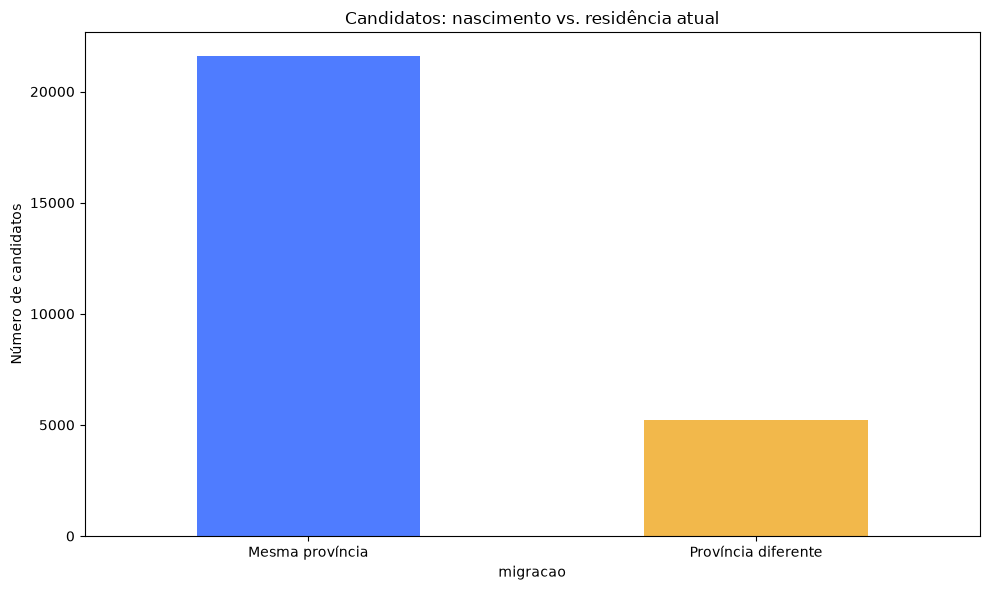

In [11]:
migracao_maputo = df_candidatos[(df_candidatos['ProvNasc'] != 'Cidade De Maputo') & (df_candidatos['ProvRes'] == 'Cidade de Maputo')]
print(f"Nasceram fora de Maputo, residem em Maputo: {len(migracao_maputo)}")
print()
print("De onde vieram:")
print(migracao_maputo['ProvNasc'].value_counts())
plt.figure(figsize=(10, 6))
df_candidatos['migracao'].value_counts().plot(kind='bar', color=['#4F7CFF', '#F2B84B'])
plt.xticks([0, 1], ['Mesma província', 'Província diferente'], rotation=0)
plt.ylabel('Número de candidatos')
plt.title('Candidatos: nascimento vs. residência atual')
plt.tight_layout()
plt.show()

In [12]:
df_candidatos.groupby('migracao')['UEM_Opc1'].apply(lambda x: x.value_counts().head(25))

migracao                                                                          
False     Medicina - Diurno - Uem                                                     1179
          Engenharia De Petróleo E Gás Natural - Diurno - Uem                          386
          Engenharia Eléctrica - Diurno - Uem                                          374
          Direito - Diurno - Uem                                                       287
          Engenharia Mecânica - Diurno - Uem                                           279
          Engenharia Informática - Diurno - Uem                                        270
          Engenharia Civil - Diurno - Uem                                              263
          Contabilidade E Finanças - Diurno - Uem                                      167
          Engenharia Electrónica - Diurno - Uem                                        128
          Ensino De Inglês - Diurno - Uem                                              120
       

Top 15 distritos de residência dos candidatos: distrito_residencia
Matola Cidade          6426
Kamubukwana            3212
Kamavota               3053
Kampfumo               1950
Kamaxaquene            1608
Marracuene             1519
Boane                   944
Kanlhamankulu           775
Cidade De Nampula       533
Cidade Da Beira         479
Cidade De Quelimane     435
Cidade De Xai-Xai       378
Xai-Xai                 314
Katembe                 302
Manhiça                 292
Name: count, dtype: int64


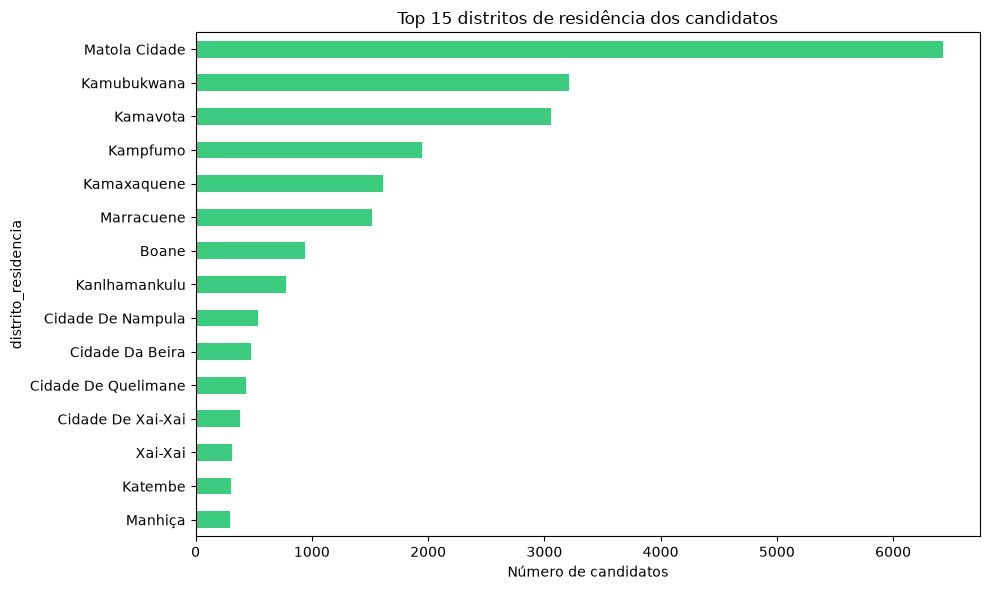

In [13]:
por_distrito = df_candidatos['distrito_residencia'].value_counts().head(15)
print(f"Top 15 distritos de residência dos candidatos: {por_distrito}")

plt.figure(figsize=(10, 6))
por_distrito.plot(kind='barh', color='#3CCB7F')
plt.gca().invert_yaxis()
plt.xlabel('Número de candidatos')
plt.title('Top 15 distritos de residência dos candidatos')
plt.tight_layout()
plt.show()

In [14]:
n_estrangeiros = (df_candidatos['ProvNasc'] == 'Estrangeiro').sum()
pct_estrangeiros = n_estrangeiros / len(df_candidatos) * 100
print(f"Candidatos estrangeiros: {n_estrangeiros} ({pct_estrangeiros:.2f}%)")

# países de origem (distrito_nascimento carrega o país quando ProvNasc == 'Estrangeiro')
df_candidatos[df_candidatos['ProvNasc'] == 'Estrangeiro']['distrito_nascimento'].value_counts()

Candidatos estrangeiros: 119 (0.44%)


distrito_nascimento
Estrangeiro    119
Name: count, dtype: int64

In [15]:

df_paises = df_candidatos['pais_nascimento'].value_counts().to_frame(name='Total')

df_paises['Percentagem (%)'] = df_candidatos['pais_nascimento'].value_counts(normalize=True) * 100

df_paises.head(35)


,Total,Percentagem (%)
pais_nascimento,,
Mocambique,26678,99.555920
Africa Do Sul,78,0.291077
Suazilandia,8,0.029854
Burundi,8,0.029854
Ruanda,6,0.022391
Inglaterra,4,0.014927
Portugal,2,0.007464
Brasil,2,0.007464
Estrangeiro,2,0.007464


In [16]:
# cursos mais procurados especificamente por candidatos estrangeiros
df_candidatos[df_candidatos['ProvNasc'] == 'Estrangeiro']['UEM_Opc1'].value_counts().head(10)

UEM_Opc1
Medicina - Diurno - Uem                    13
Direito - Diurno - Uem                     12
Engenharia Mecânica - Diurno - Uem          9
Engenharia Informática - Diurno - Uem       8
Engenharia Química - Diurno - Uem           6
Gestão - Diurno - Uem                       5
Biologia E Saúde - Diurno - Uem             5
Contabilidade E Finanças - Diurno - Uem     5
Economia - Diurno - Uem                     4
Administração Pública - Diurno - Uem        3
Name: count, dtype: int64

## Demografia — sexo, estado civil, idade

In [17]:
print(df_candidatos['Sexo'].value_counts())
print()
print(df_candidatos['EstCivil'].value_counts())

Sexo
Feminino     15580
Masculino    11217
Name: count, dtype: int64

EstCivil
Solteiro(A)      26541
Casado(A)          242
Divorciado(A)       10
Viúvo(A)             4
Name: count, dtype: int64


count    26797.000000
mean        20.807255
std          4.076333
min         15.000000
25%         18.000000
50%         20.000000
75%         22.000000
max         64.000000
Name: idade, dtype: float64


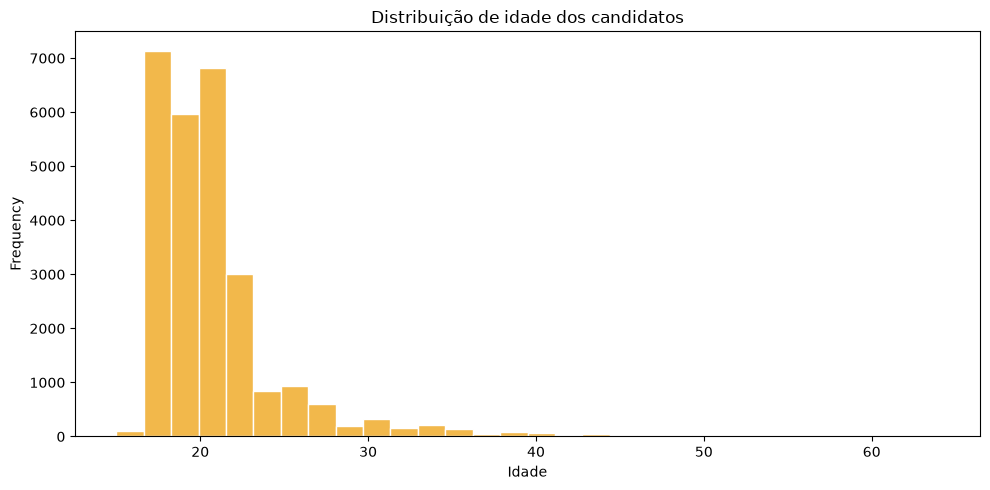

In [18]:
df_candidatos['idade'] = 2026 - pd.to_datetime(df_candidatos['data_Nasc']).dt.year

print(df_candidatos['idade'].describe())

plt.figure(figsize=(10, 5))
df_candidatos['idade'].plot(kind='hist', bins=30, color='#F2B84B', edgecolor='white')
plt.xlabel('Idade')
plt.title('Distribuição de idade dos candidatos')
plt.tight_layout()
plt.show()

In [19]:
#idade media por curso
idade_por_curso = df_candidatos.groupby('UEM_Opc1')['idade'].agg(['mean', 'median', 'std', 'count']).round(1)
idade_por_curso = idade_por_curso.sort_values('count', ascending=False)
idade_por_curso.columns = ['idade_media', 'idade_mediana', 'desvio_padrao', 'n_candidatos']
idade_por_curso.head(20)

,idade_media,idade_mediana,desvio_padrao,n_candidatos
UEM_Opc1,,,,
Medicina - Diurno - Uem,20.4,19.0,4.0,3507
Direito - Diurno - Uem,20.4,19.0,4.0,2154
Engenharia Informática - Diurno - Uem,19.3,19.0,2.0,1626
Contabilidade E Finanças - Diurno - Uem,20.0,19.0,2.5,1589
Engenharia Eléctrica - Diurno - Uem,19.7,19.0,2.4,1280
Engenharia Mecânica - Diurno - Uem,19.5,19.0,2.2,1191
Engenharia De Petróleo E Gás Natural - Diurno - Uem,19.7,19.0,3.4,1188
Engenharia Civil - Diurno - Uem,19.4,19.0,2.3,939
Gestão - Diurno - Uem,20.4,20.0,2.7,796


In [20]:
top15_cursos = procura_total.head(15)['curso'].tolist()
idade_top15 = df_candidatos[df_candidatos['UEM_Opc1'].isin(top15_cursos)].groupby('UEM_Opc1')['idade'].agg(['mean', 'median', 'count']).round(1)
idade_top15 = idade_top15.sort_values('mean', ascending=False)
idade_top15.columns = ['idade_media', 'idade_mediana', 'n_candidatos']
idade_top15

,idade_media,idade_mediana,n_candidatos
UEM_Opc1,,,
Administração Pública - Diurno - Uem,21.4,21.0,795
Marketing E Relações Públicas - Diurno - Uem,21.2,20.0,445
Biologia E Saúde - Diurno - Uem,20.8,20.0,409
Gestão - Diurno - Uem,20.4,20.0,796
Medicina - Diurno - Uem,20.4,19.0,3507
Direito - Diurno - Uem,20.4,19.0,2154
Engenharia De Telecomunicações - Diurno - Uem,20.1,20.0,225
Economia - Diurno - Uem,20.0,19.0,581
Contabilidade E Finanças - Diurno - Uem,20.0,19.0,1589


C:\Users\belci\AppData\Local\Temp\ipykernel_4948\3486187432.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(dados_plot, tick_labels=top15_cursos, vert=False)


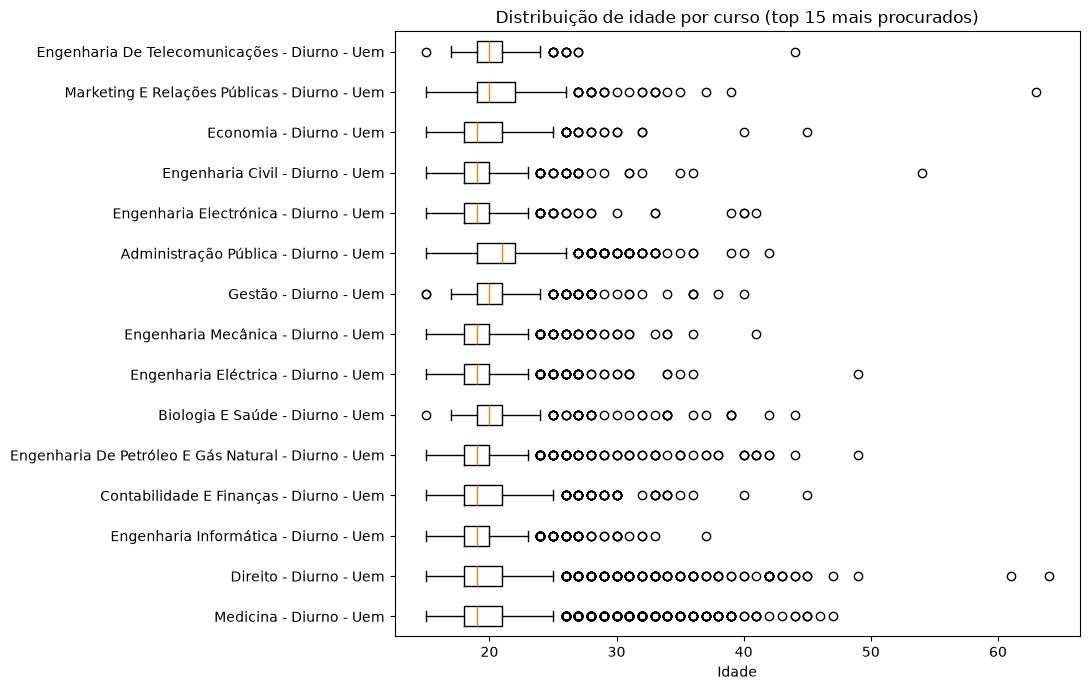

In [21]:
plt.figure(figsize=(11, 7))
dados_plot = [df_candidatos[df_candidatos['UEM_Opc1'] == curso]['idade'].dropna() for curso in top15_cursos]
plt.boxplot(dados_plot, tick_labels=top15_cursos, vert=False)
plt.xlabel('Idade')
plt.title('Distribuição de idade por curso (top 15 mais procurados)')
plt.tight_layout()
plt.show()

In [22]:
idade_estrangeiros = df_candidatos[df_candidatos['ProvNasc'] == 'Estrangeiro']['idade']
print("Idade dos candidatos estrangeiros:")
print(idade_estrangeiros.describe())
print()
print("Comparação com candidatos nacionais:")
print(df_candidatos[df_candidatos['ProvNasc'] != 'Estrangeiro']['idade'].describe())

Idade dos candidatos estrangeiros:
count    119.000000
mean      20.252101
std        2.867759
min       15.000000
25%       19.000000
50%       19.000000
75%       21.000000
max       36.000000
Name: idade, dtype: float64

Comparação com candidatos nacionais:
count    26678.000000
mean        20.809731
std          4.080791
min         15.000000
25%         18.000000
50%         20.000000
75%         22.000000
max         64.000000
Name: idade, dtype: float64


In [23]:
estrangeiros_por_curso = df_candidatos[df_candidatos['ProvNasc'] == 'Estrangeiro'].groupby('UEM_Opc1')['idade'].agg(['mean', 'count']).round(1)
estrangeiros_por_curso = estrangeiros_por_curso.sort_values('count', ascending=False)
estrangeiros_por_curso.columns = ['idade_media', 'n_candidatos']
estrangeiros_por_curso.head(15)

,idade_media,n_candidatos
UEM_Opc1,,
Medicina - Diurno - Uem,20.2,13
Direito - Diurno - Uem,19.8,12
Engenharia Mecânica - Diurno - Uem,19.4,9
Engenharia Informática - Diurno - Uem,19.1,8
Engenharia Química - Diurno - Uem,19.0,6
Biologia E Saúde - Diurno - Uem,19.2,5
Gestão - Diurno - Uem,20.2,5
Contabilidade E Finanças - Diurno - Uem,18.6,5
Economia - Diurno - Uem,20.2,4


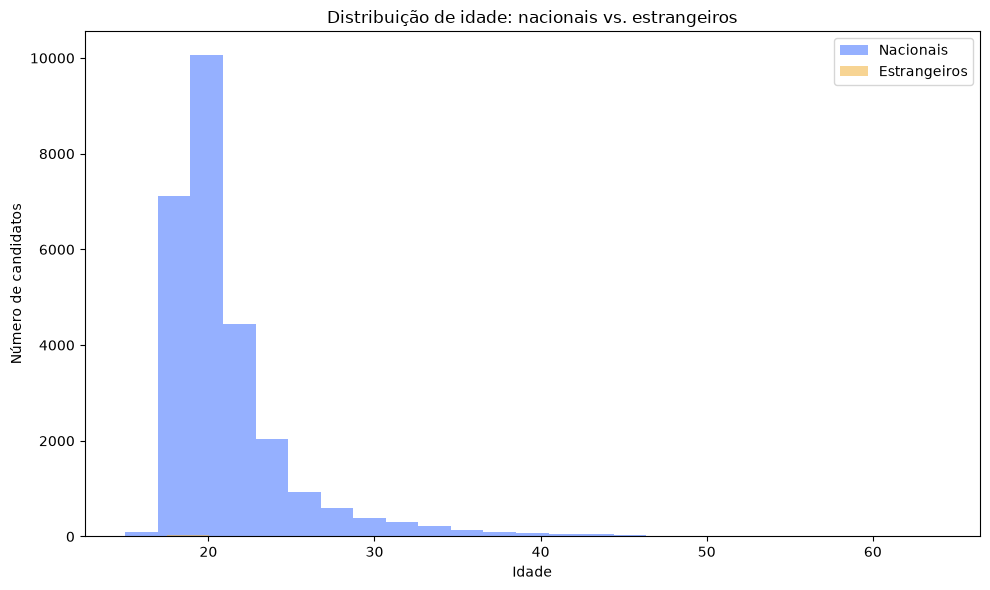

In [24]:
plt.figure(figsize=(10, 6))
plt.hist(df_candidatos[df_candidatos['ProvNasc'] != 'Estrangeiro']['idade'].dropna(), bins=25, alpha=0.6, label='Nacionais', color='#4F7CFF')
plt.hist(df_candidatos[df_candidatos['ProvNasc'] == 'Estrangeiro']['idade'].dropna(), bins=25, alpha=0.6, label='Estrangeiros', color='#F2B84B')
plt.xlabel('Idade')
plt.ylabel('Número de candidatos')
plt.title('Distribuição de idade: nacionais vs. estrangeiros')
plt.legend()
plt.tight_layout()
plt.show()

## Cruzamento — género por curso (top 10 mais procurados)

In [25]:
top10_cursos = procura_total.head(10)['curso'].tolist()
cruzamento_genero = df_candidatos[df_candidatos['UEM_Opc1'].isin(top10_cursos)].groupby(['UEM_Opc1', 'Sexo']).size().unstack(fill_value=0)
cruzamento_genero['%_feminino'] = (cruzamento_genero.get('Feminino', 0) /
                                     cruzamento_genero.sum(axis=1) * 100).round(1)
cruzamento_genero.sort_values('%_feminino')

Sexo,Feminino,Masculino,%_feminino
UEM_Opc1,,,
Engenharia Mecânica - Diurno - Uem,318,873,26.7
Engenharia Informática - Diurno - Uem,461,1165,28.4
Engenharia Eléctrica - Diurno - Uem,412,868,32.2
Engenharia De Petróleo E Gás Natural - Diurno - Uem,619,569,52.1
Contabilidade E Finanças - Diurno - Uem,1059,530,66.6
Gestão - Diurno - Uem,577,219,72.5
Direito - Diurno - Uem,1576,578,73.2
Medicina - Diurno - Uem,2652,855,75.6
Administração Pública - Diurno - Uem,620,175,78.0


In [26]:
print("Top 20 escolas por número de candidatos:")
df_candidatos['EscoPU'].value_counts().head(20)

Top 20 escolas por número de candidatos:


EscoPU
Outra - Província De Maputo                     2396
Desconhecida - Cidade De Maputo                 2244
Outra - Cidade De Maputo                         864
Escola Secundária De Machava Sede                809
Desconhecida - Província De Maputo               803
Escola Secundária Da Zona-Verde                  644
Escola Secundária Bonifácio Gruveta Massamba     643
Escola Secundária De Laulane                     599
Escola Secundária Noroeste 1                     592
Escola Secundária Heróis Moçambicanos            588
Escola Secundária Quisse Mavota                  587
Escola Secundária Da Matola                      573
Escola Secundária Joaquim Alberto Chissano       547
Escola Secundária Francisco Manyanga             537
Escola Secundária Eduardo Mondlane               535
Escola Secundária Da Liberdade                   497
Escola Secundária De Malhazine                   450
Escola Secundária De Nkobe                       439
Escola Secundária Força Do Povo        

In [27]:
# para os top 5 cursos mais procurados, quais as 3 escolas que mais alimentam cada um
top5_cursos = procura_total.head(5)['curso'].tolist()
for curso in top5_cursos:
    print(f"\n{curso}:")
    print(df_candidatos[df_candidatos['UEM_Opc1'] == curso]['EscoPU'].value_counts().head(3))


Medicina - Diurno - Uem:
EscoPU
Outra - Província De Maputo           300
Desconhecida - Cidade De Maputo       242
Desconhecida - Província De Maputo     99
Name: count, dtype: int64

Direito - Diurno - Uem:
EscoPU
Outra - Província De Maputo              206
Desconhecida - Cidade De Maputo          204
Escola Secundária Heróis Moçambicanos     73
Name: count, dtype: int64

Engenharia Informática - Diurno - Uem:
EscoPU
Desconhecida - Cidade De Maputo    174
Outra - Província De Maputo        156
Outra - Cidade De Maputo            69
Name: count, dtype: int64

Contabilidade E Finanças - Diurno - Uem:
EscoPU
Desconhecida - Cidade De Maputo    172
Outra - Província De Maputo        157
Outra - Cidade De Maputo            77
Name: count, dtype: int64

Engenharia De Petróleo E Gás Natural - Diurno - Uem:
EscoPU
Outra - Província De Maputo        91
Desconhecida - Cidade De Maputo    77
Outra - Cidade De Maputo           44
Name: count, dtype: int64


In [28]:
print(df_candidatos['AnocPU'].value_counts().sort_index(ascending=False).head(15))

n_direto = (df_candidatos['AnocPU'] == 2025).sum()
pct_direto = n_direto / len(df_candidatos) * 100
print(f"\nCandidatos vindos direto do secundário (concluído em 2025): {n_direto} ({pct_direto:.1f}%)")

AnocPU
2025    11346
2024     6920
2023     3263
2022     1525
2021     1278
2020      495
2019      477
2018      407
2017      198
2016      184
2015      122
2014       75
2013      104
2012       90
2011       74
Name: count, dtype: int64

Candidatos vindos direto do secundário (concluído em 2025): 11346 (42.3%)


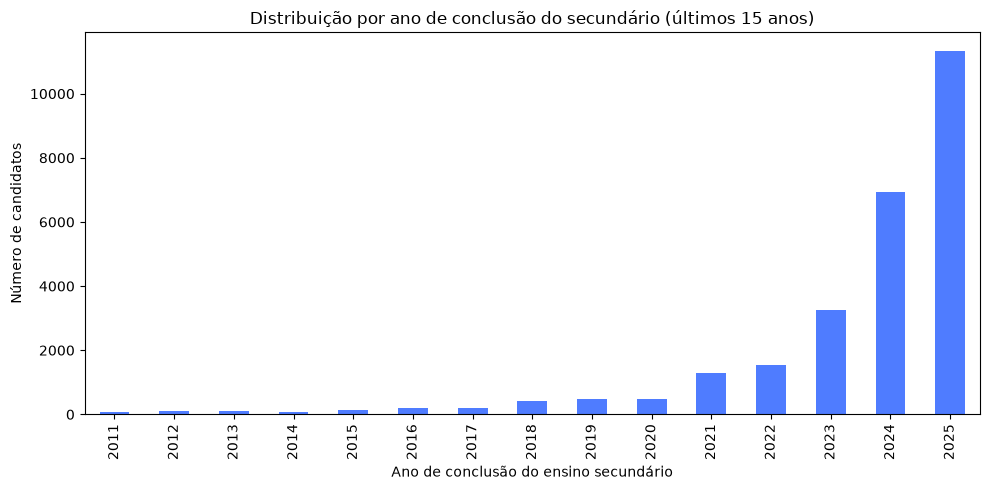

In [29]:
plt.figure(figsize=(10, 5))
df_candidatos['AnocPU'].value_counts().sort_index().tail(15).plot(kind='bar', color='#4F7CFF')
plt.xlabel('Ano de conclusão do ensino secundário')
plt.ylabel('Número de candidatos')
plt.title('Distribuição por ano de conclusão do secundário (últimos 15 anos)')
plt.tight_layout()
plt.show()

In [30]:
print("Top 15 locais de exame:")
print(df_candidatos['local_exame'].value_counts().head(15))

# candidatos onde o local de exame é diferente do distrito de residência 
deslocados = (df_candidatos['local_exame'].str.strip().str.title() != df_candidatos['distrito_residencia'].str.strip().str.title()).sum()
pct_deslocados = deslocados / len(df_candidatos) * 100
print(f"\nCandidatos com local de exame diferente do distrito de residência: {deslocados} ({pct_deslocados:.1f}%)")


Top 15 locais de exame:
local_exame
Cidade De Maputo       15937
Província De Maputo     4563
Chongoene               1044
Cidade De Nampula        837
Cidade Da Beira          669
Cidade De Quelimane      586
Maxixe                   512
Cidade De Inhambane      504
Cidade De Chimoio        448
Chibuto                  428
Cidade De Tete           362
Cidade De Pemba          321
Cidade De Lichinga       247
Vilankulo                227
Mocuba                   112
Name: count, dtype: int64

Candidatos com local de exame diferente do distrito de residência: 24555 (91.6%)


In [31]:
procura_total.to_csv('../outputs/eda_procura_demografia/resumo_procura_por_curso.csv', index=False)
por_provincia.to_csv('../outputs/eda_procura_demografia/resumo_por_provincia.csv')
por_distrito.to_csv('../outputs/eda_procura_demografia/resumo_por_distrito.csv')
df_paises.to_csv('../outputs/eda_procura_demografia/resumo_por_pais.csv', index=True)
cruzamento_genero.to_csv('../outputs/eda_procura_demografia/resumo_genero_por_curso.csv')
df_candidatos['EscoPU'].value_counts().to_csv('../outputs/eda_procura_demografia/resumo_por_escola.csv')
df_candidatos['AnocPU'].value_counts().to_csv('../outputs/eda_procura_demografia/resumo_por_ano_conclusao.csv')
idade_por_curso.to_csv('../outputs/eda_procura_demografia/resumo_idade_por_curso.csv')
idade_top15.to_csv('../outputs/eda_procura_demografia/resumo_idade_top15_cursos.csv')
estrangeiros_por_curso.to_csv('../outputs/eda_procura_demografia/resumo_idade_estrangeiros_por_curso.csv')
cruzamento_prov.to_csv('../outputs/eda_procura_demografia/resumo_migracao_provincia.csv')
idade_estrangeiros.to_csv('../outputs/eda_procura_demografia/resumo_idade_estrangeiros.csv')

print("Tabelas-resumo guardadas.")

Tabelas-resumo guardadas.
